In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from datetime import datetime
import itertools
import json
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from pathlib import Path
import random
import regex as re
import sys
import tldextract
import seaborn as sns
sys.path.append(str(Path(f"../../../global_helpers").resolve()))
sys.path.append(str(Path(f"../../../longitudinal/analysis/plotting").resolve()))
from connecttodb import connect_to_db
from histplot import *

In [3]:
fig_path = Path(f"../../../../paper/img/httparchive/").resolve()


In [4]:
style_path = Path(f"../../../global_helpers/theme_bw.mplstyle").resolve()
plt.style.use(style_path)
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=["#77AADD", "#99DDFF", "#44BB99", "#BBCC33","#AAAA00","#EEDD88", "#EE8866","#FFAABB", "#DDDDDD"])

In [5]:
data_path = Path("../../../../data/httparchive/summary/ast/threshold5/threshold_testing_ast_data.json").resolve()
with open(data_path ) as json_file:
    output = json.load(json_file)

In [6]:
o1, o2, o3, o5, o10 = list(),list(),list(),list(),list()

for s1, s2, s3,s5,s10 in output["done"]:
    try:
        o1.append(1-json.loads(s1.rstrip())["normalized"])
        o2.append(1-json.loads(s2.rstrip())["normalized"])
        o3.append(1-json.loads(s3.rstrip())["normalized"])
        o5.append(1-json.loads(s5.rstrip())["normalized"])
        o10.append(1-json.loads(s10.rstrip())["normalized"])
    except:
        pass

In [7]:
print(o1)
print(o2)
print(o3)
print(o5)
print(o10)

[0.05221386800334171, 0.11275676628757825, 0.4275, 0.09019030982807763, 0.04848621103117501, 0.08873292392530396, 0.0595161635624063, 0.8791208791208791, 0.0, 0.03787812362998688, 0.020697585281717168, 0.0864770748694138, 0.12294440093970238, 0.21101376720901122, 0.0, 0.42328042328042326, 0.13402115304852757, 0.31881188118811876, 0.030616645105648987, 0.0, 0.023745277927684882, 0.01763485477178428, 0.023745277927684882, 0.0942249240121581, 0.35449798243531927, 0.07719410634208845, 0.0, 0.03316603715010091, 0.2031984492367337, 0.0, 0.0, 0.19575253924284397, 0.07719410634208845, 0.0, 0.28125, 0.0, 0.12294440093970238, 0.053137586072495746, 0.14269631297495078, 0.02287991733707284, 0.03232323232323231, 0.015870120394016807, 0.0, 0.11158042942625834, 0.08997632202052086, 0.0, 0.16584269662921347, 0.32110579479000534, 0.06101949025487252, 0.12129017807145259, 0.0, 0.5142118863049095, 0.01791572041382794, 0.04653567735263697, 0.7894626803261551, 0.0, 0.29504489068603934, 0.10834483172355869,

In [8]:
print(print(pd.Series(o1).describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.995])))

count    25000.000000
mean         0.102699
std          0.141839
min          0.000000
25%          0.009539
50%          0.051863
75%          0.130945
90%          0.267760
99.5%        0.869588
max          1.000000
dtype: float64
None


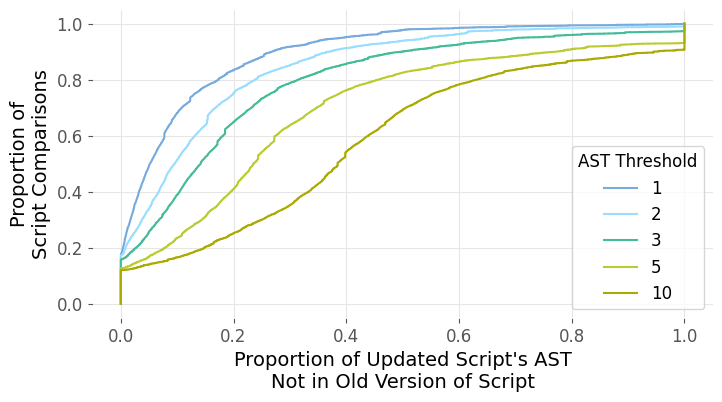

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(np.sort(o1), np.linspace(0, 1, len(o1), endpoint=False), label="1", drawstyle='steps-post')
plt.plot(np.sort(o2), np.linspace(0, 1, len(o2), endpoint=False), label="2", drawstyle='steps-post')
plt.plot(np.sort(o3), np.linspace(0, 1, len(o3), endpoint=False), label="3", drawstyle='steps-post')
plt.plot(np.sort(o5), np.linspace(0, 1, len(o5), endpoint=False), label="5", drawstyle='steps-post')
plt.plot(np.sort(o10), np.linspace(0, 1, len(o10), endpoint=False), label="10", drawstyle='steps-post')
plt.legend(fontsize = 12, title="AST Threshold", title_fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ylabel("Proportion of\nScript Comparisons", fontsize=14)
plt.xlabel("Proportion of Updated Script's AST\nNot in Old Version of Script", fontsize=14)
plt.savefig(f"{fig_path}/http_audit_test_thresholds.pdf",bbox_inches="tight", format='pdf', dpi=1200)
plt.show()

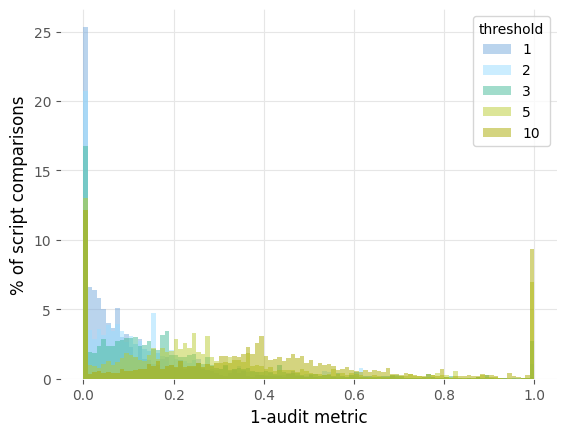

In [10]:
plt.hist(np.sort(o1), label="1", alpha=.5, density = True, bins=100)
plt.hist(np.sort(o2), label="2",alpha=.5, density = True, bins=100)
plt.hist(np.sort(o3), label="3",alpha=.5, density = True, bins=100)
plt.hist(np.sort(o5), label="5",alpha=.5, density = True, bins=100)
plt.hist(np.sort(o10), label="10",alpha=.5, density = True, bins=100)
plt.legend(title="threshold")
plt.ylabel("% of script comparisons")
plt.xlabel("1-audit metric")
plt.savefig(f"{fig_path}/http_audit_test_thresholds_hist.pdf",bbox_inches="tight", format='pdf', dpi=1200)

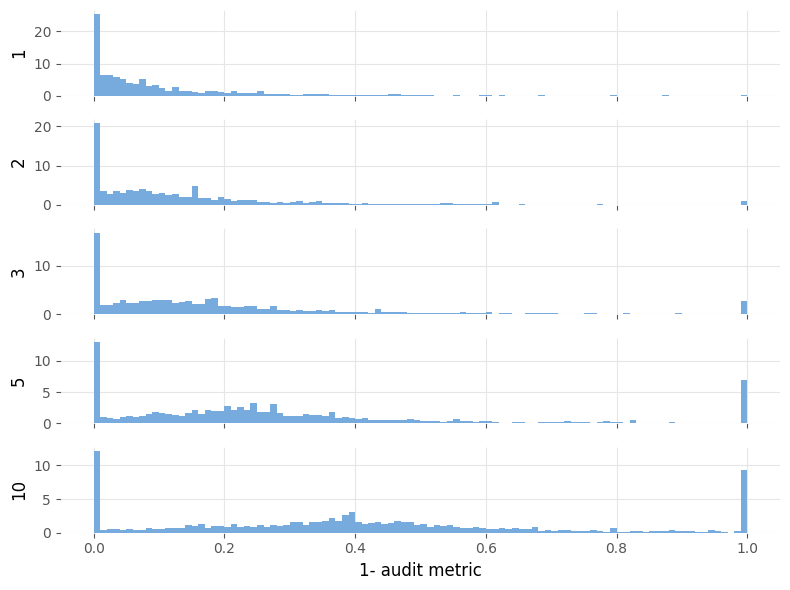

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Generate dummy datasets for the 5 histograms
np.random.seed(42)
data_sets = [np.random.randn(1000) + i for i in range(5)]

# Create a figure with 5 vertically stacked subplots
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(8, 6), sharex=True)


data= [(o1, "1"),(o2, "2"),(o3, "3"),(o5, "5"),(o10, "10")]
# Loop through the axes and plot each histogram
for i, ax in enumerate(axes):
    ax.hist(data[i][0], bins=100,density=True)
    ax.set_ylabel(data[i][1])

# Add common x-axis label and clean up the layout
axes[-1].set_xlabel('1- audit metric')
plt.tight_layout()
plt.savefig(f"{fig_path}/http_audit_test_thresholds_hist_sep.pdf",bbox_inches="tight", format='pdf', dpi=1200)
plt.show()